In [6]:
!pip install wordcloud

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

In [8]:
df = pd.read_csv("tweet_data.csv")
df.head()

,tweetID,crDate,edInput,editor,engages,isApproved,isEdNeed,isRT,likes,photoUrl,retweets,rtUsID,text,topicName,usFlwrs,usID,usName,videoUrl
0,1070867471245164544,2018-12-07 02:27:55,-1,-1,98,False,True,False,64,https://pbs.twimg.com/media/Dtx8SiIWkAImVsb.jpg,34,-1,The immediate impulse for an alliance of the E...,Business,23464532,5988062,The Economist,NaN
1,1070868017888837633,2018-12-07 02:30:05,-1,-1,13,False,True,False,10,https://pbs.twimg.com/media/Dtx8yTyW4AEciqP.jpg,3,-1,America's economy is flashing some warning sig...,Business,1732809,16184358,CNN Business,NaN
2,1070868012864028673,2018-12-07 02:30:04,-1,-1,12,False,True,False,8,NaN,4,-1,Lyft files for what is expected to be one of t...,Business,2253989,25053299,FORTUNE,NaN
3,1070867995239555075,2018-12-07 02:30:00,-1,-1,5,False,True,False,4,NaN,1,-1,"Exporters still waiting to get Rs 6,000 crore ...",Business,1704056,43855487,Business Standard,NaN
4,1070867995205885952,2018-12-07 02:30:00,-1,-1,5,False,True,False,2,NaN,3,-1,Ride-hailing firm Lyft races to leave Uber beh...,Business,1997662,15110357,Reuters Business,https://video.twimg.com/amplify_video/10708116...


In [9]:
print("Total tweets:", len(df))

print("Oldest tweet:", df["crDate"].min())
print("Most recent tweet:", df["crDate"].max())

Total tweets: 785916
Oldest tweet: 2006-11-01 03:33:20
Most recent tweet: 2019-07-24 23:59:07


In [10]:
print("Number of unique edInput values:", df["edInput"].nunique())
print("Unique edInput values:", df["edInput"].unique())

Number of unique edInput values: 5
Unique edInput values: [-1  1  2  3  4]


In [11]:
df_labeled = df[df["edInput"] != -1]
print("Tweets after filtering:", len(df_labeled))

Tweets after filtering: 363251


In [12]:
print("Number of unique topics:", df_labeled["topicName"].nunique())
print("Topics:", df_labeled["topicName"].unique())

Number of unique topics: 42
Topics: ['Fashion' 'Interesting' 'Art' 'Animal' 'Personal Development' 'News'
 'Business' 'DIY & Craft' 'Poem' 'World Leaders' 'Entrepreneurship'
 'US News' 'Travel' 'Journalists' 'Funny' 'Flowers' 'Cryptocurrency'
 'Fitness' 'Spirituality' 'Design & Architecture' 'Startup' 'Memes'
 'Technology' 'Space' 'Digital Media & Internet' 'Psychology' 'Science'
 'Photography' 'Basketball' 'Humor' 'Mindfulness' 'Nature' 'Medical'
 'Motivational' 'Informative' 'Love' 'Editorial Pics' 'Stocks' 'Nanotech'
 'Biotech' 'science' 'Random']


In [13]:
topic_counts = df_labeled["topicName"].value_counts()
print("Most populated topic:", topic_counts.idxmax(), "with", topic_counts.max(), "tweets")

Most populated topic: News with 43227 tweets


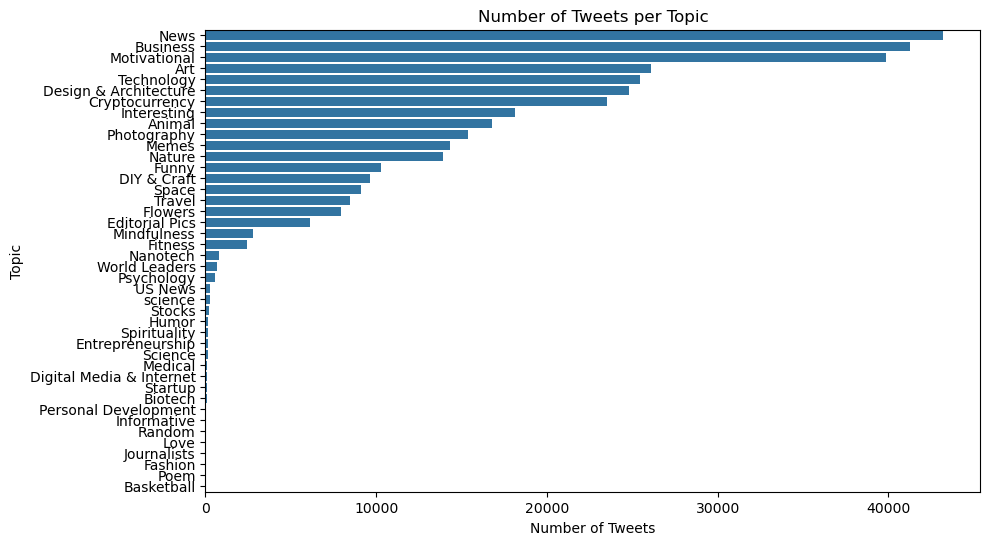

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(y="topicName", data=df_labeled, order=df_labeled["topicName"].value_counts().index)
plt.title("Number of Tweets per Topic")
plt.xlabel("Number of Tweets")
plt.ylabel("Topic")
plt.show()

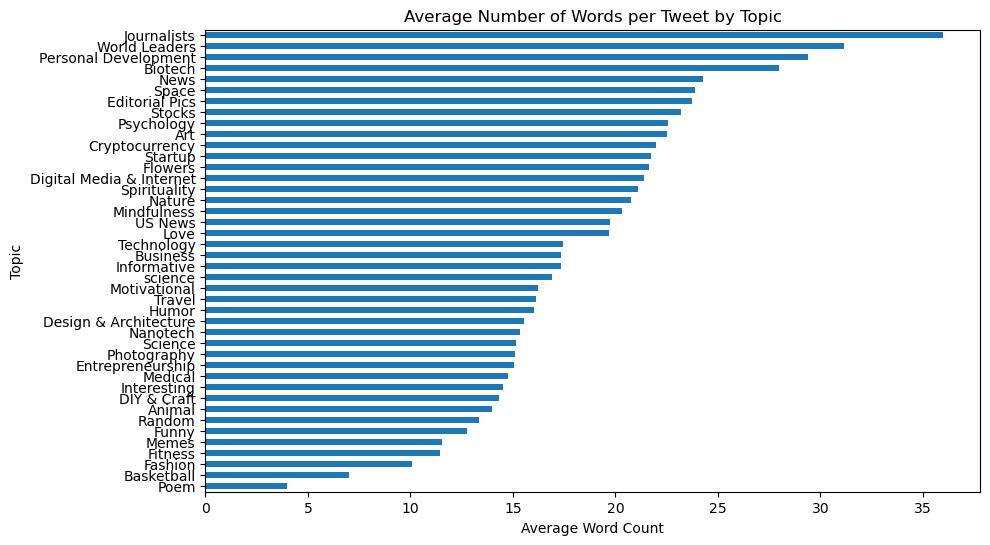

In [17]:
# Add word_count safely
df_labeled = df_labeled.copy()
df_labeled.loc[:, "word_count"] = df_labeled["text"].astype(str).str.split().str.len()

avg_words = df_labeled.groupby("topicName")["word_count"].mean()

plt.figure(figsize=(10,6))
avg_words.sort_values().plot(kind="barh")
plt.title("Average Number of Words per Tweet by Topic")
plt.xlabel("Average Word Count")
plt.ylabel("Topic")
plt.show()

In [18]:
tech_df = df_labeled[df_labeled["topicName"] == "Technology"].copy()

# Add char_count safely
tech_df.loc[:, "char_count"] = tech_df["text"].astype(str).str.len()
longest_tweet = tech_df.loc[tech_df["char_count"].idxmax()]

print("Longest Technology tweet length (characters):", longest_tweet["char_count"])
print("Tweet text:")
print(longest_tweet["text"])

Longest Technology tweet length (characters): 744
Tweet text:
@AdamRogers2030 @Parul_RajeevM @jack @TwitterIndia @verified @mashable @Twitter @biz @sriramk @paraga @PattyArquette @ABAlbrectsen @afreenundp @kumarmanish9 @samanthabarry @RachelintheOC @DrDebaratiH @ManavSubodh @FolukeMichael @VeeVohra @deespeak @manishm345 @Policy @mrsfunnybones @womensmarch @kapoors_s @ranjanakumari @Elif_Safak @VincentCoyle1 @EObsidian @RobertoValentUN @kateatoyw @poet_economist @FemnetProg @AWID @SustWomen @iamcolinquinn @jack @vijaya @manishm345 @biz @iamcolinquinn @MomentsIndia @verified 
Exposing the Bias Embedded in Tech @TwitterWomen @Policy 

@smritiirani @deespeak 
@Microsoft’s @PeggyJ put it, “The best way to turn anything around is to shine a light on it.”
https://t.co/zp2YUTtKjC https://t.co/LVyWIRrI0t


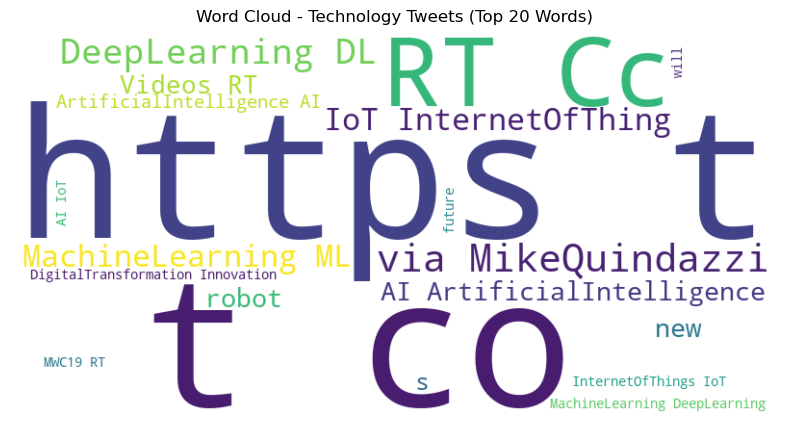

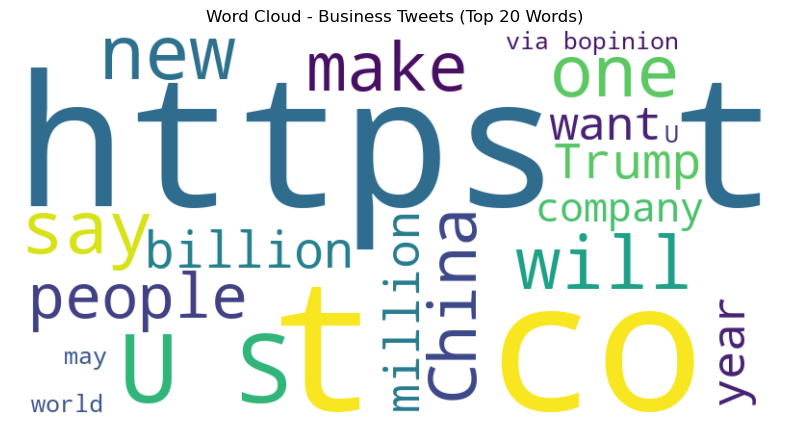

Most common words in Technology:
['https t', 't co', 'RT Cc', 'via MikeQuindazzi', 'DeepLearning DL', 'IoT InternetOfThing', 'MachineLearning ML', 'AI ArtificialIntelligence', 'new', 'robot', 'Videos RT', 's', 'ArtificialIntelligence AI', 'DigitalTransformation Innovation', 'AI IoT', 'MachineLearning DeepLearning', 'future', 'InternetOfThings IoT', 'will', 'MWC19 RT']

Most common words in Business:
['https t', 't co', 'U S', 'new', 'will', 'say', 'one', 'make', 'China', 'people', 'billion', 'Trump', 'million', 'want', 'year', 'company', 'via bopinion', 'U', 'may', 'world']


In [19]:
stopwords = set(STOPWORDS)

# Technology word cloud
tech_text = " ".join(tech_df["text"].astype(str))
wordcloud_tech = WordCloud(width=800, height=400, max_words=20,
                           background_color="white", stopwords=stopwords).generate(tech_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_tech, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Technology Tweets (Top 20 Words)")
plt.show()

# Business word cloud
business_df = df_labeled[df_labeled["topicName"] == "Business"]
business_text = " ".join(business_df["text"].astype(str))
wordcloud_business = WordCloud(width=800, height=400, max_words=20,
                               background_color="white", stopwords=stopwords).generate(business_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_business, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Business Tweets (Top 20 Words)")
plt.show()

# Compare top words
print("Most common words in Technology:")
print(list(wordcloud_tech.words_.keys())[:20])

print("\nMost common words in Business:")
print(list(wordcloud_business.words_.keys())[:20])